# 연차별 FMS/PMS/SMS 잔여비율 분석 및 CR 예측

**요구사항**: HND_SVC — 연차별 FMS/PMS/SMS 잔여비율 확인  
**목적**: 차량 출고 후 연차별 FMS 쿠폰 소진 패턴 분석 + 미사용 쿠폰 보유 차량 예측(CR 타겟)

| 분석 항목 | 방법 |
|---|---|
| 연차별 FMS 잔여비율 | Agora/BPKTWS svc_propo + co_vehic 조인 → 연차 계산 → 누적 사용 집계 |
| FMS/PMS/SMS 구분 | svc_type_fms_cd 코드 매핑 (10000001~05=FMS, 06~11=PMS, 12+=SMS) |
| FCT 교차검증 | Karete FCT_SERVICE_REPAIR.IS_FMS_INCLUDE |
| CR 예측 모델 | LightGBM — 다음 1년 내 FMS 사용 여부 예측 |


## 0. 설정 & 라이브러리

적용 폰트: ['Malgun Gothic']


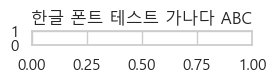

데이터 경로: c:\Project\toyota_project\MCB-ML-toyota_project\louis\data\hnd_svc


In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ─────────────────────────────────────────────────────
# sns.set_theme() 이 rcParams를 초기화하므로, set_theme() 이후에 폰트를 덮어써야 함
sns.set_theme(style='whitegrid', palette='muted')

_FONT_PATH = 'C:/Windows/Fonts/malgun.ttf'
if os.path.exists(_FONT_PATH):
    fm.fontManager.addfont(_FONT_PATH)
    mpl.rcParams['font.family'] = 'Malgun Gothic'
else:
    # Malgun Gothic 없으면 시스템에서 한글 폰트 탐색
    _candidates = [f.name for f in fm.fontManager.ttflist
                   if any(k in f.name for k in ('Gothic', 'Gulim', 'Dotum', 'Batang'))]
    if _candidates:
        mpl.rcParams['font.family'] = _candidates[0]

mpl.rcParams['axes.unicode_minus'] = False

print(f"적용 폰트: {mpl.rcParams['font.family']}")

# ── 테스트 플롯 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3, 1))
ax.set_title('한글 폰트 테스트 가나다 ABC')
plt.tight_layout(); plt.show(); plt.close()

# ── 경로 & 파라미터 ────────────────────────────────────────────────────
DATA_DIR   = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'data', 'hnd_svc')
RESULT_DIR = os.path.join(DATA_DIR, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

# FMS 코드 매핑 — Karete 확인: 10K(12M)=1차, 20K(24M)=2차 ... 50K(60M)=5차
FMS_STANDARD_CODES = {str(10000000 + i): f'FMS_{i}차' for i in range(1, 6)}
FMS_EXTENDED_CODES = {str(10000000 + i): f'PMS_{i-5}차' for i in range(6, 12)}
FMS_SMS_CODES      = {str(10000000 + i): f'SMS_{i-11}차' for i in range(12, 24)}
FMS_ALL_MAP        = {**FMS_STANDARD_CODES, **FMS_EXTENDED_CODES, **FMS_SMS_CODES}

FMS_TOTAL = 5  # 표준 FMS 쿠폰 총 수 (실제 마스터 확인 후 조정)

print(f"데이터 경로: {os.path.abspath(DATA_DIR)}")

## 1. 데이터 로드

In [2]:
def load_pq(filename, required=True):
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        df = pd.read_parquet(path)
        print(f"  ✓ {filename:45s}  {df.shape[0]:>10,} × {df.shape[1]:>3} cols")
        return df
    elif required:
        raise FileNotFoundError(f"{filename} 없음 → 02_manage_storage.ipynb 먼저 실행")
    else:
        print(f"  - {filename:45s}  (미존재, 건너뜀)")
        return None

print("=== Agora (TMKR_L) ===")
agora_propo      = load_pq('agora_svc_propo.parquet')
agora_propo_part = load_pq('agora_svc_propo_part.parquet')
agora_vehic      = load_pq('agora_co_vehic.parquet')
agora_contract   = load_pq('agora_om_contract.parquet')
agora_svc_cr     = load_pq('agora_l_svc_cr.parquet')
agora_cr_vehic   = load_pq('agora_svc_cr_vehic.parquet')

print("\n=== BP/KTWS (KPI_L) ===")
bp_propo    = load_pq('bpktws_svc_propo.parquet')
bp_vehic    = load_pq('bpktws_co_vehic.parquet')
bp_contract = load_pq('bpktws_om_contract.parquet')

print("\n=== Karete ===")
karete_fct      = load_pq('karete_fct_svc_repair.parquet')
karete_propo    = load_pq('karete_svc_propo.parquet',   required=False)
karete_vehic    = load_pq('karete_co_vehic.parquet',    required=False)
karete_contract = load_pq('karete_om_contract.parquet', required=False)

=== Agora (TMKR_L) ===
  ✓ agora_svc_propo.parquet                           715,582 ×  12 cols
  ✓ agora_svc_propo_part.parquet                    2,550,629 ×   8 cols
  ✓ agora_co_vehic.parquet                            227,613 ×  10 cols
  ✓ agora_om_contract.parquet                         231,924 ×   8 cols
  ✓ agora_l_svc_cr.parquet                                165 ×  41 cols
  ✓ agora_svc_cr_vehic.parquet                        264,563 ×  10 cols

=== BP/KTWS (KPI_L) ===
  ✓ bpktws_svc_propo.parquet                          775,020 ×  12 cols
  ✓ bpktws_co_vehic.parquet                           227,613 ×  10 cols
  ✓ bpktws_om_contract.parquet                        231,924 ×   8 cols

=== Karete ===
  ✓ karete_fct_svc_repair.parquet                     571,275 ×  16 cols
  ✓ karete_svc_propo.parquet                        5,072,378 ×  14 cols
  ✓ karete_co_vehic.parquet                           357,365 ×  11 cols
  ✓ karete_om_contract.parquet                        384,69

## 2. 데이터 전처리 & 통합

In [3]:
# ── 2-1. svc_propo 통합 (Agora lowercase + BPKTWS UPPERCASE → 공통 포맷) ──────
PROPO_COLS = ['VIN','SHOP_CD','PROPO_DT','PROPO_SEQ','SVC_MODEL_CD',
              'ODOMETER','SVC_TYPE_FMS_CD','STAT_CD','WORK_CLOSE_YN']

agora_p = agora_propo.rename(columns={
    'vin':'VIN','shop_cd':'SHOP_CD','propo_dt':'PROPO_DT','propo_seq':'PROPO_SEQ',
    'svc_model_cd':'SVC_MODEL_CD','odometer':'ODOMETER',
    'svc_type_fms_cd':'SVC_TYPE_FMS_CD','stat_cd':'STAT_CD','work_close_yn':'WORK_CLOSE_YN'
})[PROPO_COLS].assign(SOURCE='agora')

bp_p = bp_propo.rename(columns=str.upper)[PROPO_COLS].assign(SOURCE='bpktws')

propo = pd.concat([agora_p, bp_p], ignore_index=True)
propo = propo.drop_duplicates(['VIN','PROPO_DT','PROPO_SEQ'], keep='first')
propo['PROPO_DT'] = pd.to_datetime(propo['PROPO_DT'].astype(str), format='%Y%m%d', errors='coerce')
propo = propo.dropna(subset=['PROPO_DT'])

# FMS 유형 분류
propo['FMS_TYPE_LABEL'] = propo['SVC_TYPE_FMS_CD'].map(FMS_ALL_MAP).fillna('기타')
propo['IS_STANDARD_FMS'] = propo['SVC_TYPE_FMS_CD'].isin(FMS_STANDARD_CODES)
propo['SHOP_REGION'] = propo['SHOP_CD'].str[:2]

print(f"통합 propo: {len(propo):,} rows ({propo['VIN'].nunique():,} unique VINs)")
print(f"\nFMS 유형별 건수:")
display(propo['FMS_TYPE_LABEL'].value_counts().head(10).to_frame('건수'))

통합 propo: 775,019 rows (177,568 unique VINs)

FMS 유형별 건수:


,건수
FMS_TYPE_LABEL,
FMS_2차,133555
FMS_1차,129395
FMS_3차,114934
FMS_4차,103499
FMS_5차,89374
PMS_1차,49650
PMS_2차,31144
PMS_3차,26291
PMS_4차,22645


In [4]:
# ── 2-2. co_vehic 통합 + 실제 출고일(om_contract) 우선 적용 ─────────────────
VEHIC_COLS = ['VIN','MODEL_CD','SVC_MODEL_CD','MODEL_YEAR','DELIVERY_DT','SALES_TYPE','FIRST_OWNER_YN']

agora_v = agora_vehic.rename(columns={c: c.upper() for c in agora_vehic.columns})[VEHIC_COLS].assign(SOURCE='agora')
bp_v    = bp_vehic.rename(columns=str.upper)[VEHIC_COLS].assign(SOURCE='bpktws')

vehic = pd.concat([agora_v, bp_v], ignore_index=True)
vehic['DELIVERY_DT'] = pd.to_datetime(vehic['DELIVERY_DT'], errors='coerce')
vehic = vehic.dropna(subset=['DELIVERY_DT'])
vehic = vehic[vehic['DELIVERY_DT'].dt.year.between(2000, 2030)]
vehic = vehic.sort_values('DELIVERY_DT').drop_duplicates('VIN', keep='first')

# 실제 출고일 (delivery_actual_dt) 우선 적용
def parse_actual(df_contract, vin_col, dt_col):
    tmp = df_contract[[vin_col, dt_col]].rename(columns={vin_col:'VIN', dt_col:'ACTUAL_DT'}).copy()
    tmp['ACTUAL_DT'] = pd.to_datetime(tmp['ACTUAL_DT'], errors='coerce')
    return tmp.dropna().query("ACTUAL_DT.dt.year.between(2000, 2030)", engine='python')

actual = pd.concat([
    parse_actual(agora_contract, 'vin', 'delivery_actual_dt'),
    parse_actual(bp_contract, 'vin', 'delivery_actual_dt'),
], ignore_index=True).sort_values('ACTUAL_DT').drop_duplicates('VIN', keep='first')

vehic = vehic.merge(actual, on='VIN', how='left')
vehic['DELIVERY_FINAL'] = vehic['ACTUAL_DT'].combine_first(vehic['DELIVERY_DT'])

print(f"vehic: {len(vehic):,} unique VINs")
print(f"실제 출고일 확보: {vehic['ACTUAL_DT'].notna().sum():,} / {len(vehic):,}")

vehic: 227,543 unique VINs
실제 출고일 확보: 184,036 / 227,543


## 3. 연차 계산

In [5]:
# svc_propo × co_vehic 조인 → 연차(연도 기준) 계산
df = propo.merge(
    vehic[['VIN','MODEL_CD','SVC_MODEL_CD','MODEL_YEAR','DELIVERY_FINAL','SALES_TYPE','FIRST_OWNER_YN']],
    on='VIN', how='inner'
)

df['VEHICLE_AGE_DAYS']  = (df['PROPO_DT'] - df['DELIVERY_FINAL']).dt.days
df = df[(df['VEHICLE_AGE_DAYS'] > 30) & (df['VEHICLE_AGE_DAYS'] < 365 * 12)]

df['VEHICLE_AGE_YEARS'] = df['VEHICLE_AGE_DAYS'] / 365.25
df['VEHICLE_AGE_YEAR']  = (df['VEHICLE_AGE_YEARS'].astype(int) + 1).clip(1, 10)  # 1~10연차

print(f"분석 DataFrame: {df.shape[0]:,} rows, {df['VIN'].nunique():,} unique VINs")
print(f"\n연차별 FMS 서비스 건수:")
display(df['VEHICLE_AGE_YEAR'].value_counts().sort_index().rename('건수').to_frame())

분석 DataFrame: 723,096 rows, 173,858 unique VINs

연차별 FMS 서비스 건수:


,건수
VEHICLE_AGE_YEAR,
1,246285
2,212327
3,79482
4,57957
5,40633
6,26782
7,19617
8,15255
9,10418


## 4. FMS 사용 현황 분석

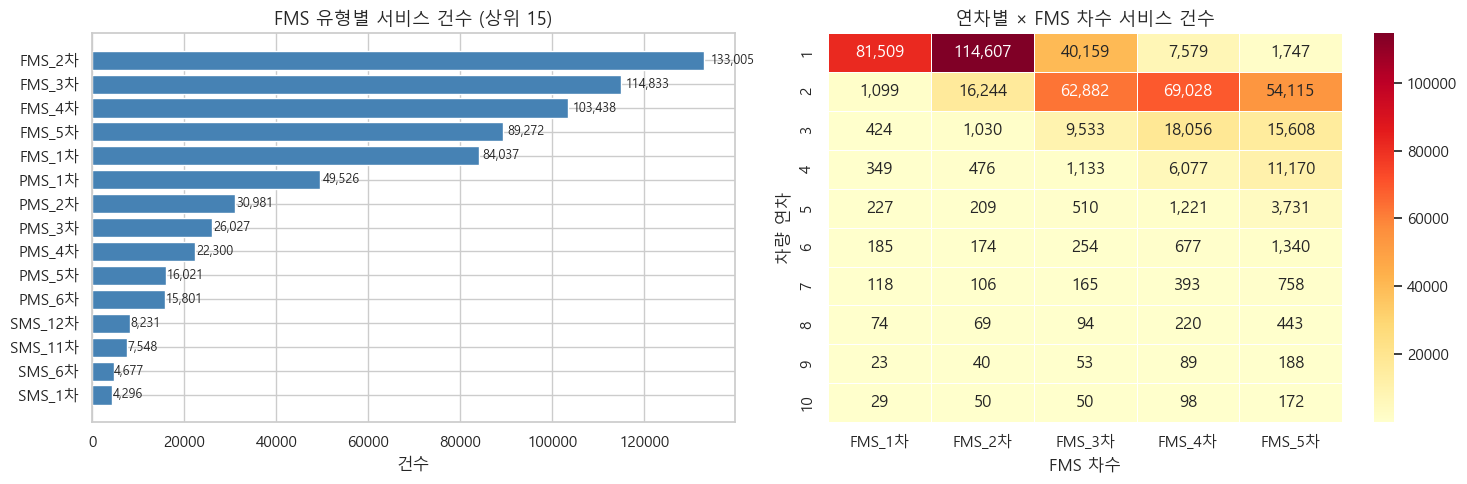

In [6]:
# ── 4-1. 연차별 FMS 유형 분포 ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 좌: FMS 유형별 전체 건수
type_cnt = df['FMS_TYPE_LABEL'].value_counts().head(15)
axes[0].barh(type_cnt.index[::-1], type_cnt.values[::-1], color='steelblue')
axes[0].set_title('FMS 유형별 서비스 건수 (상위 15)', fontsize=13)
axes[0].set_xlabel('건수')
for i, v in enumerate(type_cnt.values[::-1]):
    axes[0].text(v * 1.01, i, f'{v:,}', va='center', fontsize=9)

# 우: 연차별 × FMS유형 Heatmap (표준 FMS 1~5차)
pivot = (
    df[df['IS_STANDARD_FMS']]
    .groupby(['VEHICLE_AGE_YEAR','FMS_TYPE_LABEL'])
    .size().unstack(fill_value=0)
)
# 컬럼 정렬
fms_cols = [c for c in [f'FMS_{i}차' for i in range(1,6)] if c in pivot.columns]
pivot = pivot[fms_cols]

sns.heatmap(pivot, annot=True, fmt=',d', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('연차별 × FMS 차수 서비스 건수', fontsize=13)
axes[1].set_xlabel('FMS 차수')
axes[1].set_ylabel('차량 연차')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'fms_type_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── 4-2. VIN별 FMS 사용 현황 (누적) ──────────────────────────────────────
# 표준 FMS(1~5차) 기준
std_propo = df[df['IS_STANDARD_FMS']].copy()

# VIN별로 몇 차 FMS까지 사용했는지 (최대 차수)
vin_fms_max = (
    std_propo.groupby('VIN')['SVC_TYPE_FMS_CD']
    .apply(lambda x: x.nunique())
    .reset_index()
    .rename(columns={'SVC_TYPE_FMS_CD': 'FMS_TYPES_USED'})
)

# VIN별 최근 FMS 연차
vin_last_age = (
    std_propo.groupby('VIN')['VEHICLE_AGE_YEAR']
    .max()
    .reset_index()
    .rename(columns={'VEHICLE_AGE_YEAR': 'LAST_FMS_AGE_YEAR'})
)

vin_summary = vin_fms_max.merge(vin_last_age, on='VIN')
vin_summary['FMS_REMAINING'] = (FMS_TOTAL - vin_summary['FMS_TYPES_USED']).clip(0)
vin_summary['FMS_REMAINING_RATIO'] = vin_summary['FMS_REMAINING'] / FMS_TOTAL

print(f"FMS 분석 대상 VIN: {len(vin_summary):,}대")
print(f"\nFMS 사용 차수 분포:")
display(vin_summary['FMS_TYPES_USED'].value_counts().sort_index().rename('VIN 수').to_frame())

FMS 분석 대상 VIN: 159,213대

FMS 사용 차수 분포:


,VIN 수
FMS_TYPES_USED,
1,27968
2,31639
3,37754
4,41616
5,20236


## 5. 연차별 FMS 잔여비율

In [8]:
# ── 5-1. 연차별 누적 FMS 사용 집계 ─────────────────────────────────────────
MAX_AGE = 7

# VIN별 연차별 FMS 사용 횟수 (표준 FMS만)
fms_by_vin_year = (
    std_propo.groupby(['VIN','VEHICLE_AGE_YEAR'])
    .agg(
        fms_count      = ('SVC_TYPE_FMS_CD', 'count'),
        fms_types_used = ('SVC_TYPE_FMS_CD', 'nunique'),
        last_odo       = ('ODOMETER', 'max'),
    ).reset_index()
)

# 전체 연차-VIN 크로스조인 (1~MAX_AGE)
all_ages  = pd.DataFrame({'VEHICLE_AGE_YEAR': range(1, MAX_AGE + 1)})
snap_base = vehic[['VIN','MODEL_CD','SVC_MODEL_CD','MODEL_YEAR','DELIVERY_FINAL','SALES_TYPE','FIRST_OWNER_YN']].copy()
snap_base['_key'] = 1
all_ages['_key']  = 1
snap = snap_base.merge(all_ages, on='_key').drop('_key', axis=1)

# 스냅샷 날짜 = 출고일 + 연차 (벡터 연산)
snap['SNAP_DATE'] = snap['DELIVERY_FINAL'] + pd.to_timedelta(
    snap['VEHICLE_AGE_YEAR'].astype(float) * 365.25, unit='D'
)

# 스냅샷 날짜가 오늘 이전인 행만 (과거 & 현재 차량만)
TODAY = pd.Timestamp.today().normalize()
snap  = snap[snap['SNAP_DATE'] <= TODAY]

# 해당 연차의 FMS 사용 수 병합
snap = snap.merge(
    fms_by_vin_year.rename(columns={'fms_types_used': 'fms_used_this_year',
                                     'fms_count':      'visits_this_year'}),
    on=['VIN','VEHICLE_AGE_YEAR'], how='left'
)
snap['fms_used_this_year'] = snap['fms_used_this_year'].fillna(0).astype(int)

# 누적 합산
snap = snap.sort_values(['VIN','VEHICLE_AGE_YEAR'])
snap['fms_cumulative']    = snap.groupby('VIN')['fms_used_this_year'].cumsum().clip(0, FMS_TOTAL)
snap['fms_remaining']     = (FMS_TOTAL - snap['fms_cumulative']).clip(0)
snap['fms_remaining_ratio'] = snap['fms_remaining'] / FMS_TOTAL
snap['has_remaining_fms']   = (snap['fms_remaining'] > 0).astype(int)

print(f"스냅샷 데이터: {len(snap):,} rows ({snap['VIN'].nunique():,} unique VINs)")

스냅샷 데이터: 1,226,665 rows (212,714 unique VINs)


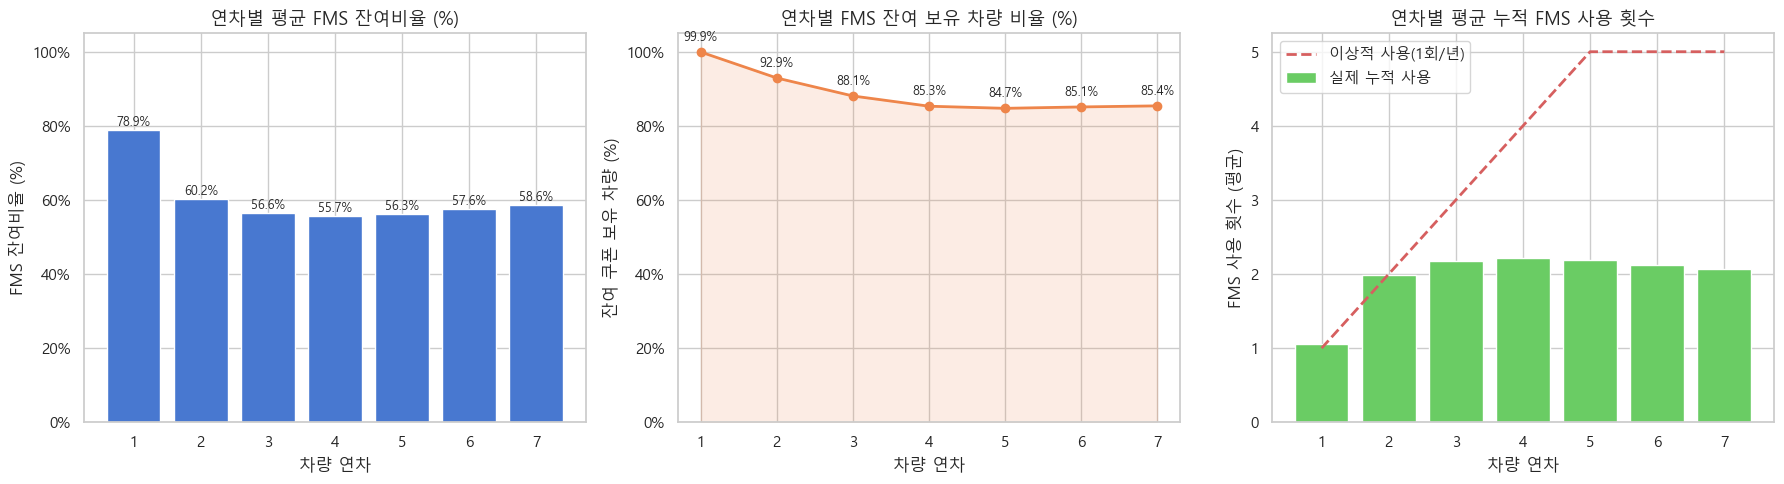

 VEHICLE_AGE_YEAR  avg_remaining_ratio  pct_has_remaining  avg_fms_cumulative  vehicle_count
                1             0.788900           0.999140            1.055502         212714
                2             0.602244           0.929040            1.988779         197394
                3             0.565507           0.880554            2.172463         183848
                4             0.557214           0.852958            2.213929         173039
                5             0.563006           0.847237            2.184968         163174
                6             0.575754           0.850996            2.121229         152331
                7             0.585859           0.853897            2.070704         144165


In [9]:
# ── 5-2. 연차별 FMS 잔여비율 시각화 ─────────────────────────────────────────
age_summary = (
    snap.groupby('VEHICLE_AGE_YEAR')
    .agg(
        avg_remaining_ratio   = ('fms_remaining_ratio', 'mean'),
        pct_has_remaining     = ('has_remaining_fms', 'mean'),
        avg_fms_cumulative    = ('fms_cumulative', 'mean'),
        vehicle_count         = ('VIN', 'nunique'),
    ).reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ① 연차별 평균 FMS 잔여비율
ax = axes[0]
bars = ax.bar(age_summary['VEHICLE_AGE_YEAR'], age_summary['avg_remaining_ratio'] * 100,
              color=sns.color_palette('muted')[0], edgecolor='white')
ax.set_title('연차별 평균 FMS 잔여비율 (%)', fontsize=13)
ax.set_xlabel('차량 연차')
ax.set_ylabel('FMS 잔여비율 (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 105)
for bar, v in zip(bars, age_summary['avg_remaining_ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{v*100:.1f}%', ha='center', fontsize=9)

# ② 연차별 FMS 잔여 보유 차량 비율
ax = axes[1]
ax.plot(age_summary['VEHICLE_AGE_YEAR'], age_summary['pct_has_remaining'] * 100,
        marker='o', linewidth=2, color=sns.color_palette('muted')[1])
ax.fill_between(age_summary['VEHICLE_AGE_YEAR'], age_summary['pct_has_remaining'] * 100,
                alpha=0.15, color=sns.color_palette('muted')[1])
ax.set_title('연차별 FMS 잔여 보유 차량 비율 (%)', fontsize=13)
ax.set_xlabel('차량 연차')
ax.set_ylabel('잔여 쿠폰 보유 차량 (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 105)
for x, y in zip(age_summary['VEHICLE_AGE_YEAR'], age_summary['pct_has_remaining']):
    ax.annotate(f'{y*100:.1f}%', (x, y*100), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

# ③ 연차별 평균 누적 FMS 사용 횟수
ax = axes[2]
ax.bar(age_summary['VEHICLE_AGE_YEAR'], age_summary['avg_fms_cumulative'],
       color=sns.color_palette('muted')[2], edgecolor='white', label='실제 누적 사용')
ax.plot(age_summary['VEHICLE_AGE_YEAR'],
        [min(y, FMS_TOTAL) for y in age_summary['VEHICLE_AGE_YEAR']],
        'r--', linewidth=2, label='이상적 사용(1회/년)')
ax.set_title('연차별 평균 누적 FMS 사용 횟수', fontsize=13)
ax.set_xlabel('차량 연차')
ax.set_ylabel('FMS 사용 횟수 (평균)')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'fms_remaining_by_age.png'), dpi=150, bbox_inches='tight')
plt.show()
print(age_summary.to_string(index=False))

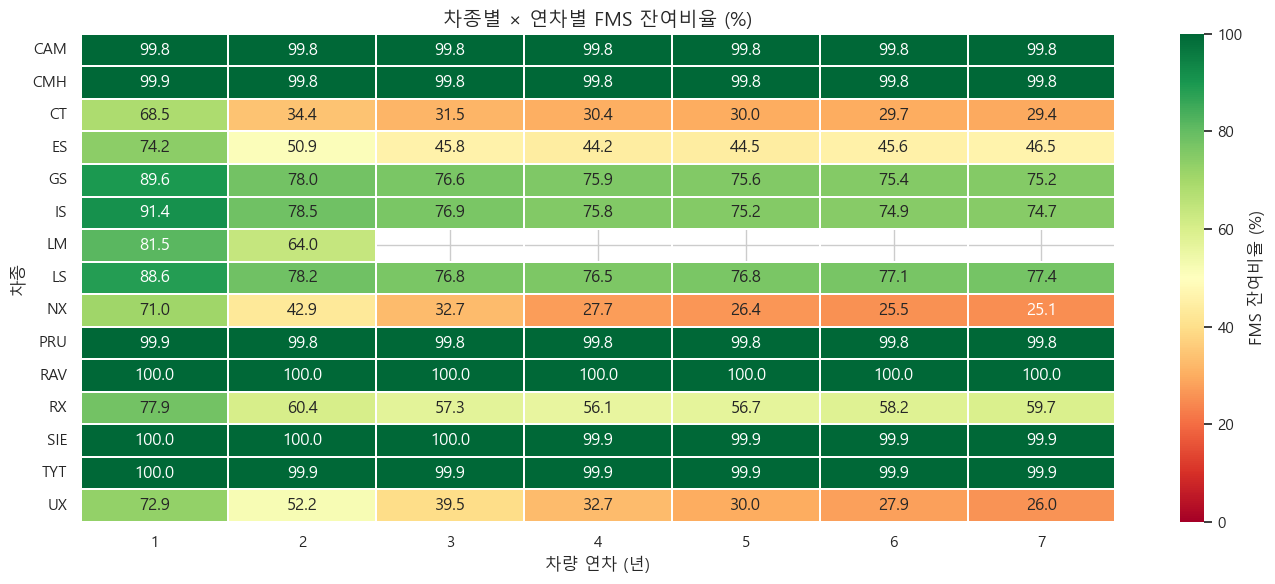

In [10]:
# ── 5-3. 차종(MODEL_CD)별 연차별 잔여비율 ─────────────────────────────────
model_age = (
    snap.groupby(['MODEL_CD','VEHICLE_AGE_YEAR'])['fms_remaining_ratio']
    .mean().unstack(fill_value=np.nan)
)
# 데이터 충분한 차종만 (전체 연차에 걸쳐 500대 이상)
model_counts = snap.groupby('MODEL_CD')['VIN'].nunique()
top_models = model_counts[model_counts >= 500].index
model_age = model_age.loc[model_age.index.isin(top_models)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    model_age * 100,
    annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
    linewidths=0.3, cbar_kws={'label': 'FMS 잔여비율 (%)'},
    vmin=0, vmax=100
)
ax.set_title('차종별 × 연차별 FMS 잔여비율 (%)', fontsize=14)
ax.set_xlabel('차량 연차 (년)')
ax.set_ylabel('차종')
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'fms_remaining_by_model.png'), dpi=150, bbox_inches='tight')
plt.show()

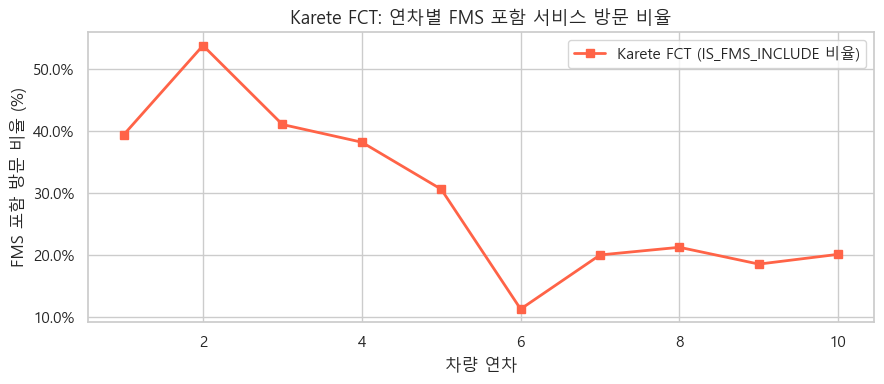

,VEHICLE_AGE_YEAR,fms_visits,total_visits,unique_vins,fms_visit_rate
0,1,36752,93251,45271,0.394119
1,2,35368,65680,34769,0.538490
2,3,20007,48693,28129,0.410880
3,4,17034,44562,24140,0.382254
4,5,11361,37097,22966,0.306251
5,6,5659,50234,30580,0.112653
6,7,10451,52228,33031,0.200103
7,8,8983,42279,27593,0.212470
8,9,5461,29468,19493,0.185320
9,10,11059,54985,27552,0.201128


In [11]:
# ── 5-4. Karete FCT 교차검증 (IS_FMS_INCLUDE 기반) ──────────────────────────
karete_fct['RO_DATE'] = pd.to_datetime(karete_fct['RO_DATE'], errors='coerce')

if karete_vehic is not None:
    # 실제 출고일 기준 연차 계산
    kv = karete_vehic[['VIN','DELIVERY_DATE']].copy()
    kv['DELIVERY_DATE'] = pd.to_datetime(kv['DELIVERY_DATE'], errors='coerce')
    kv = kv.dropna().drop_duplicates('VIN', keep='first')
    fct = karete_fct.merge(kv, on='VIN', how='left')
    fct['VEH_AGE_DAYS'] = (fct['RO_DATE'] - fct['DELIVERY_DATE']).dt.days
    fct = fct[(fct['VEH_AGE_DAYS'] > 30) & (fct['VEH_AGE_DAYS'] < 365*12)]
    fct['VEHICLE_AGE_YEAR'] = (fct['VEH_AGE_DAYS'] / 365.25).astype(int).add(1).clip(1, 10)
else:
    # 모델 연도 기반 추정 (±1년 오차 가능)
    fct = karete_fct.copy()
    fct['VEHICLE_AGE_YEAR'] = (fct['RO_DATE'].dt.year - fct['VEHICLE_MODEL_YEAR']).clip(0, 9).add(1)

karete_fms_rate = (
    fct.groupby('VEHICLE_AGE_YEAR')
    .agg(
        fms_visits   = ('IS_FMS_INCLUDE', 'sum'),
        total_visits = ('VIN', 'count'),
        unique_vins  = ('VIN', 'nunique'),
    ).reset_index()
)
karete_fms_rate['fms_visit_rate'] = karete_fms_rate['fms_visits'] / karete_fms_rate['total_visits']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(karete_fms_rate['VEHICLE_AGE_YEAR'], karete_fms_rate['fms_visit_rate'] * 100,
        marker='s', linewidth=2, color='tomato', label='Karete FCT (IS_FMS_INCLUDE 비율)')
ax.set_title('Karete FCT: 연차별 FMS 포함 서비스 방문 비율', fontsize=13)
ax.set_xlabel('차량 연차')
ax.set_ylabel('FMS 포함 방문 비율 (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'karete_fms_validation.png'), dpi=150, bbox_inches='tight')
plt.show()
display(karete_fms_rate)

## 6. ML 예측 모델 (LightGBM)

**예측 목표**: 현재 연차에서 다음 1년 내 FMS를 사용할지 여부 (`will_use_fms_next_year`)  
**활용**: 확률 낮은 차량 = 쿠폰 미사용 위험 → CR 캠페인 우선 타겟

In [12]:
# ── 6-1. ML 특성 엔지니어링 ──────────────────────────────────────────────
# fms_by_vin_year 컬럼: fms_count, fms_types_used, last_odo
# snap 컬럼:           visits_this_year(=fms_count), fms_used_this_year(=fms_types_used)

# 다음 연차 FMS 사용 여부 (target) — fms_by_vin_year 원본 컬럼명 사용
next_year_fms = (
    fms_by_vin_year[['VIN', 'VEHICLE_AGE_YEAR', 'fms_types_used']]
    .rename(columns={'VEHICLE_AGE_YEAR': 'NEXT_AGE', 'fms_types_used': 'fms_next_year'})
    .copy()
)
next_year_fms['VEHICLE_AGE_YEAR'] = next_year_fms['NEXT_AGE'] - 1
next_year_fms = next_year_fms.drop('NEXT_AGE', axis=1)

ml_df = snap.merge(next_year_fms, on=['VIN', 'VEHICLE_AGE_YEAR'], how='left')
ml_df['will_use_fms_next_year'] = (ml_df['fms_next_year'].fillna(0) > 0).astype(int)

# 마지막 FMS 이후 경과 연차
last_fms_age = (
    std_propo.groupby('VIN')['VEHICLE_AGE_YEAR']
    .max().reset_index()
    .rename(columns={'VEHICLE_AGE_YEAR': 'LAST_FMS_AGE_YEAR'})
)
ml_df = ml_df.merge(last_fms_age, on='VIN', how='left')
ml_df['YEARS_SINCE_LAST_FMS'] = (
    ml_df['VEHICLE_AGE_YEAR'] - ml_df['LAST_FMS_AGE_YEAR']
).fillna(ml_df['VEHICLE_AGE_YEAR'])

# 딜러 지역 (VIN별 최빈 지역)
vin_region = (
    propo.groupby('VIN')['SHOP_REGION']
    .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else 'XX')
    .reset_index()
)
ml_df = ml_df.merge(vin_region, on='VIN', how='left')

FEATURES = [
    'VEHICLE_AGE_YEAR',     # 현재 연차
    'fms_cumulative',       # 누적 사용 FMS 수
    'fms_remaining',        # 잔여 FMS 수
    'fms_remaining_ratio',  # 잔여 비율
    'YEARS_SINCE_LAST_FMS', # 마지막 FMS 이후 경과 연차
    'MODEL_YEAR',           # 모델 연도
    'SVC_MODEL_CD',         # 서비스 모델 코드 (categorical)
    'MODEL_CD',             # 차종 (categorical)
    'SALES_TYPE',           # 판매 유형
    'FIRST_OWNER_YN',       # 최초 소유자 여부
    'SHOP_REGION',          # 딜러 지역
    'last_odo',             # 마지막 주행거리
]
TARGET = 'will_use_fms_next_year'

# 미래 연차(MAX_AGE) 제외 — target 없음
ml_valid = ml_df[ml_df['VEHICLE_AGE_YEAR'] < MAX_AGE].copy()
ml_valid = ml_valid.dropna(subset=['MODEL_YEAR'])

print(f"ML 데이터셋: {len(ml_valid):,} rows")
print(f"Target 분포:")
print(ml_valid[TARGET].value_counts(normalize=True).rename('비율').map('{:.1%}'.format))

ML 데이터셋: 1,082,500 rows
Target 분포:
will_use_fms_next_year
0    83.0%
1    17.0%
Name: 비율, dtype: str


In [13]:
# ── 6-2. 범주형 인코딩 & Train/Test 분리 (시간 기반) ─────────────────────
ml_data = ml_valid[FEATURES + [TARGET, 'DELIVERY_FINAL', 'VIN']].copy()

# 범주형 → LabelEncoding (정수)
CAT_COLS = ['SVC_MODEL_CD', 'MODEL_CD', 'SALES_TYPE', 'FIRST_OWNER_YN', 'SHOP_REGION']
le_dict = {}
for col in CAT_COLS:
    ml_data[col] = ml_data[col].fillna('UNKNOWN').astype(str)
    le = LabelEncoder()
    ml_data[col] = le.fit_transform(ml_data[col])
    le_dict[col] = le

# 수치형 컬럼 NaN → 0, dtype float32 통일
NUM_COLS = [f for f in FEATURES if f not in CAT_COLS]
for col in NUM_COLS:
    ml_data[col] = pd.to_numeric(ml_data[col], errors='coerce').fillna(0)

# 시간 기반 Train/Test 분리 (출고일 기준 최근 20% → Test)
cutoff    = ml_data['DELIVERY_FINAL'].quantile(0.80)
train_idx = ml_data['DELIVERY_FINAL'] < cutoff
X_train   = ml_data.loc[train_idx,  FEATURES].astype('float32')
X_test    = ml_data.loc[~train_idx, FEATURES].astype('float32')
y_train   = ml_data.loc[train_idx,  TARGET].astype(int)
y_test    = ml_data.loc[~train_idx, TARGET].astype(int)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train 결측 컬럼: {X_train.columns[X_train.isna().any()].tolist()}")
print(f"Train Target 분포: {y_train.value_counts().to_dict()}")
print(f"Test  Target 분포: {y_test.value_counts().to_dict()}")

Train: 865,602  |  Test: 216,898
Train 결측 컬럼: []
Train Target 분포: {0: 761922, 1: 103680}
Test  Target 분포: {0: 136805, 1: 80093}


In [14]:
# ── 6-3. LightGBM 학습 ──────────────────────────────────────────────────
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = round(neg / pos, 4) if pos > 0 else 1.0
print(f"클래스 비율  neg={neg:,} / pos={pos:,}  →  scale_pos_weight={scale_pos}")

lgb_params = {
    'objective':         'binary',
    'metric':            'auc',
    'learning_rate':     0.05,
    'num_leaves':        64,
    'min_child_samples': 50,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'scale_pos_weight':  scale_pos,
    'verbose':           -1,
    'seed':              42,
}

ds_train = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
ds_valid = lgb.Dataset(X_test,  label=y_test,  reference=ds_train, free_raw_data=False)

# LightGBM 버전별 호환 학습
lgb_ver = tuple(int(x) for x in lgb.__version__.split('.')[:2])
print(f"LightGBM version: {lgb.__version__}")

if lgb_ver >= (3, 3):
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=50),
    ]
    model = lgb.train(
        lgb_params, ds_train,
        num_boost_round=1000,
        valid_sets=[ds_valid],
        valid_names=['valid'],
        callbacks=callbacks,
    )
else:
    model = lgb.train(
        lgb_params, ds_train,
        num_boost_round=1000,
        valid_sets=[ds_valid],
        valid_names=['valid'],
        early_stopping_rounds=50,
        verbose_eval=50,
    )

print(f"\nBest iteration: {model.best_iteration}")

클래스 비율  neg=761,922 / pos=103,680  →  scale_pos_weight=7.3488
LightGBM version: 4.6.0
[50]	valid's auc: 0.984133

Best iteration: 3


ROC-AUC: 0.9878

분류 성능:
              precision    recall  f1-score   support

      미사용(0)       0.63      1.00      0.77    136805
       사용(1)       0.00      0.00      0.00     80093

    accuracy                           0.63    216898
   macro avg       0.32      0.50      0.39    216898
weighted avg       0.40      0.63      0.49    216898



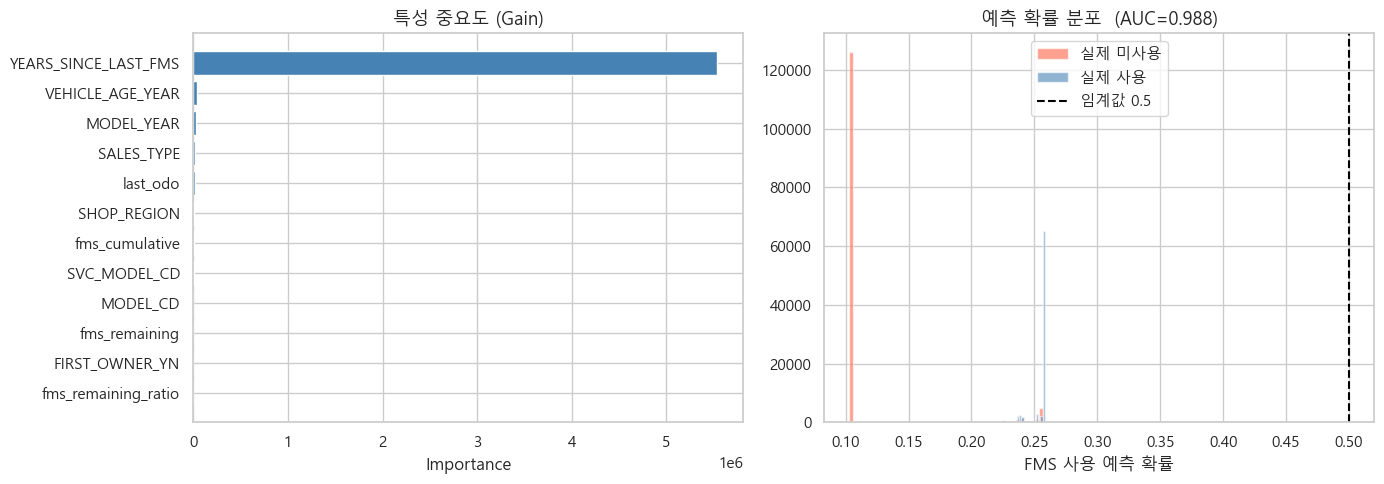

In [15]:
# ── 6-4. 모델 평가 & 특성 중요도 ────────────────────────────────────────
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = (y_pred_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC: {auc:.4f}")
print("\n분류 성능:")
print(classification_report(y_test, y_pred, target_names=['미사용(0)','사용(1)']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 특성 중요도
fi = pd.Series(model.feature_importance('gain'), index=FEATURES).sort_values(ascending=True)
axes[0].barh(fi.index, fi.values, color='steelblue')
axes[0].set_title('특성 중요도 (Gain)', fontsize=13)
axes[0].set_xlabel('Importance')

# 예측 확률 분포
axes[1].hist(y_pred_prob[y_test == 0], bins=50, alpha=0.6, label='실제 미사용', color='tomato')
axes[1].hist(y_pred_prob[y_test == 1], bins=50, alpha=0.6, label='실제 사용', color='steelblue')
axes[1].axvline(0.5, color='black', linestyle='--', label='임계값 0.5')
axes[1].set_title(f'예측 확률 분포  (AUC={auc:.3f})', fontsize=13)
axes[1].set_xlabel('FMS 사용 예측 확률')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'lgbm_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. CR 타겟 추출

**기준**: FMS 잔여 쿠폰이 있으면서 (`has_remaining_fms = 1`)  
다음 1년 내 FMS 사용 확률이 낮은 (`예측 확률 < 임계값`) 차량  
→ 적극적인 CR 인바운드 콜/DM 대상

In [16]:
# ── 7-1. 현재 시점 기준 CR 타겟 선정 ─────────────────────────────────────
# 각 VIN의 가장 최근 연차 스냅샷
current_snap = snap.loc[snap.groupby('VIN')['VEHICLE_AGE_YEAR'].idxmax()].copy()

# 딜러 지역 + 마지막 FMS 연차 병합
current_feat = (
    current_snap
    .merge(vin_region,   on='VIN', how='left')
    .merge(last_fms_age, on='VIN', how='left')
    .copy()
)

# 마지막 FMS 이후 경과 연차
current_feat['YEARS_SINCE_LAST_FMS'] = (
    current_feat['VEHICLE_AGE_YEAR'] - current_feat['LAST_FMS_AGE_YEAR']
).fillna(current_feat['VEHICLE_AGE_YEAR'])

# ── 범주형 인코딩 (학습과 동일한 LabelEncoder 재사용) ──
for col in CAT_COLS:
    current_feat[col] = current_feat[col].fillna('UNKNOWN').astype(str)
    known = set(le_dict[col].classes_)
    current_feat[col] = current_feat[col].apply(
        lambda x: x if x in known else le_dict[col].classes_[0]
    )
    current_feat[col] = le_dict[col].transform(current_feat[col])

# ── 수치형 컬럼 dtype 통일 (학습 전처리와 동일) ──
for col in NUM_COLS:
    if col in current_feat.columns:
        current_feat[col] = pd.to_numeric(current_feat[col], errors='coerce').fillna(0)

# 누락 피처 보완
for f in FEATURES:
    if f not in current_feat.columns:
        current_feat[f] = 0.0

# 예측
current_feat['pred_prob'] = model.predict(
    current_feat[FEATURES].astype('float32'),
    num_iteration=model.best_iteration,
)

# CR 타겟: FMS 잔여 있음 + 다음 1년 사용 확률 낮음
CR_PROB_THRESHOLD = 0.35

cr_targets = (
    current_feat[
        (current_feat['has_remaining_fms'] == 1) &
        (current_feat['pred_prob'] < CR_PROB_THRESHOLD)
    ][['VIN', 'MODEL_CD', 'SVC_MODEL_CD', 'VEHICLE_AGE_YEAR',
       'fms_cumulative', 'fms_remaining', 'pred_prob']]
    .sort_values('pred_prob')
)

n_all    = len(current_feat)
n_remain = int(current_feat['has_remaining_fms'].sum())
n_cr     = len(cr_targets)
print(f"전체 분석 차량:                               {n_all:,}대")
print(f"FMS 잔여 보유 차량:                           {n_remain:,}대")
print(f"CR 타겟 (잔여 있음 + 사용 확률 < {CR_PROB_THRESHOLD:.0%}): {n_cr:,}대")

display(cr_targets.head(20))


전체 분석 차량:                               212,714대
FMS 잔여 보유 차량:                           184,491대
CR 타겟 (잔여 있음 + 사용 확률 < 35%): 184,491대


,VIN,MODEL_CD,SVC_MODEL_CD,VEHICLE_AGE_YEAR,fms_cumulative,fms_remaining,pred_prob
0,ZVW30 51755158,39,57,7,0,5,0.103045
212688,ZVW523031143*****,39,57,7,0,5,0.103045
212689,ZW300001460,53,57,7,0,5,0.103045
212690,ZZE122-0160015---,53,57,7,0,5,0.103045
212691,ZZE128-0001112...,53,57,7,0,5,0.103045
212692,ZZT23100115970000,53,57,7,0,5,0.103045
212693,ZZT231002396,53,57,7,0,5,0.103045
212694,ZZW30-0004403/000,53,57,7,0,5,0.103045
212695,ZZW30000242900000,53,57,7,0,5,0.103045
212696,ZZW300002537,53,57,7,0,5,0.103045


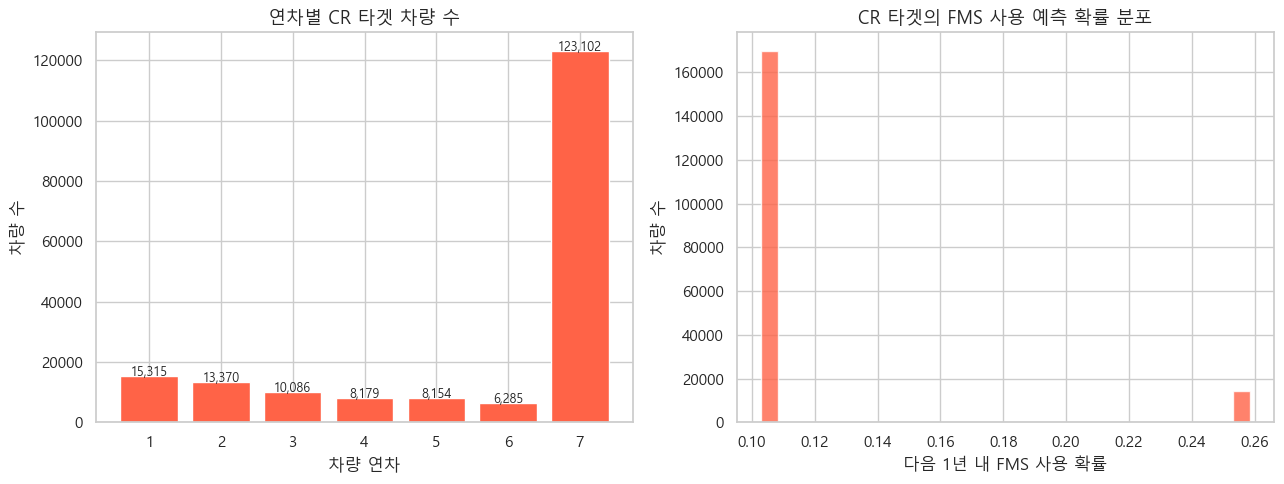

CR 타겟 저장 완료: c:\Project\toyota_project\MCB-ML-toyota_project\louis\notebook\..\data\hnd_svc\results\cr_fms_targets.csv
연차별 잔여비율 저장 완료


In [17]:
# ── 7-2. CR 타겟 시각화 & 저장 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 연차별 CR 타겟 수
cr_by_age = cr_targets.groupby('VEHICLE_AGE_YEAR').size()
axes[0].bar(cr_by_age.index, cr_by_age.values, color='tomato', edgecolor='white')
axes[0].set_title('연차별 CR 타겟 차량 수', fontsize=13)
axes[0].set_xlabel('차량 연차')
axes[0].set_ylabel('차량 수')
for x, y in zip(cr_by_age.index, cr_by_age.values):
    axes[0].text(x, y + 5, f'{y:,}', ha='center', fontsize=9)

# 예측 확률 분포 (CR 타겟 내)
axes[1].hist(cr_targets['pred_prob'], bins=30, color='tomato', alpha=0.8, edgecolor='white')
axes[1].set_title('CR 타겟의 FMS 사용 예측 확률 분포', fontsize=13)
axes[1].set_xlabel('다음 1년 내 FMS 사용 확률')
axes[1].set_ylabel('차량 수')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'cr_targets.png'), dpi=150, bbox_inches='tight')
plt.show()

# CR 타겟 CSV 저장
cr_out_path = os.path.join(RESULT_DIR, 'cr_fms_targets.csv')
cr_targets.to_csv(cr_out_path, index=False, encoding='utf-8-sig')
print(f"CR 타겟 저장 완료: {cr_out_path}")

# 연차별 FMS 잔여비율 요약 저장
age_summary.to_csv(os.path.join(RESULT_DIR, 'fms_remaining_ratio_by_age.csv'), index=False, encoding='utf-8-sig')
print(f"연차별 잔여비율 저장 완료")

---
## 결과 요약

| 산출물 | 경로 |
|---|---|
| 연차별 FMS 잔여비율 시각화 | `results/fms_remaining_by_age.png` |
| 차종별 × 연차별 Heatmap | `results/fms_remaining_by_model.png` |
| Karete FCT 교차검증 | `results/karete_fms_validation.png` |
| LightGBM 평가 결과 | `results/lgbm_evaluation.png` |
| CR 타겟 차량 리스트 (CSV) | `results/cr_fms_targets.csv` |
| 연차별 잔여비율 요약 (CSV) | `results/fms_remaining_ratio_by_age.csv` |

### 주요 파라미터 (수정 포인트)
- `FMS_TOTAL = 5` → 차종별 쿠폰 수가 다를 경우 `SVC_MODEL_CD` 기준 매핑으로 교체  
- `FMS_STANDARD_CODES` 매핑 → 실제 마스터 테이블(`L_SVC_CR` 등) 기준으로 재정의  
- `CR_PROB_THRESHOLD = 0.35` → 캠페인 예산에 따라 조정
